### OPERA DIST-S1 Confirmation DB 
In this notebook we excercise the confirmation process for OPERA DIST-S1 following as close as possible the logic used in DIST-HLS.  

In [1]:
from pathlib import Path
import numpy as np
import numpy.ma as ma
from datetime import datetime, timedelta
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from typing import List, Tuple, Optional

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


#### Sample data paths

In [2]:
# Read and subset metrics
data_dir = Path("/Users/cabrera/Desktop/spain_flood_dists")
metric_paths = sorted(list(data_dir.glob("OPERA*/*_GEN-METRIC.tif")))
metric_paths

[PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20240110T000000Z_20250226T000000Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20240110T000000Z_20250226T000000Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241031T180259Z_20250226T095718Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241031T180259Z_20250226T095718Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241106T061030Z_20250225T174139Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241106T061030Z_20250225T174139Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241107T175447Z_20250225T183623Z_S1_30_v0.1/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241107T175447Z_20250225T183623Z_S1_30_v0.1_GEN-METRIC.tif'),
 PosixPath('/Users/cabrera/Desktop/spain_flood_dists/OPERA_L3_DIST-ALERT-S1_T30SYJ_20241112T180258Z_20250226T091931Z

#### Define confidence threshold 

In [3]:
# confidence 
# confidence = N**2 * Max(metric)
confidence_threshold = 3**2 * 3.5
confidence_threshold

31.5

#### Load and visualize sample data

In [4]:
# Extract date from filenames
def extract_date_from_filename(file_path: str) -> datetime:
    """
    Extracts the date from the filename based on a specific pattern.
    
    :param file_path: The full path of the file.
    :return: The extracted date as a datetime object.
    """
    filename = Path(file_path).name
    date_str = filename.split("_")[4]  # Assuming the fourth item is the date
    # Parse the date string into a datetime object
    return datetime.strptime(date_str, "%Y%m%dT%H%M%SZ")

In [5]:
# Get the dates from the filenames
dist_product_dates = [extract_date_from_filename(str(path)) for path in metric_paths]
dist_product_dates

[datetime.datetime(2024, 1, 10, 0, 0),
 datetime.datetime(2024, 10, 31, 18, 2, 59),
 datetime.datetime(2024, 11, 6, 6, 10, 30),
 datetime.datetime(2024, 11, 7, 17, 54, 47),
 datetime.datetime(2024, 11, 12, 18, 2, 58),
 datetime.datetime(2024, 11, 13, 6, 2, 21)]

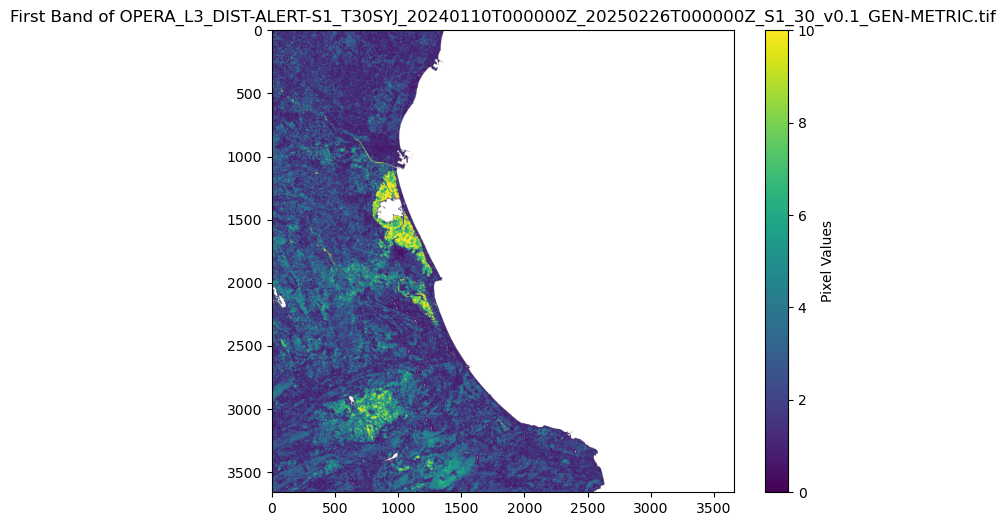

In [6]:
# Visualize and set subset
with rasterio.open(metric_paths[1]) as src:
    band1 = src.read(1)

plt.figure(figsize=(8, 6))
# plt.imshow(band1[1150:1350, 800:1000], vmin=0, vmax=10, cmap='gray')
plt.imshow(band1, vmin=0, vmax=10, cmap='viridis')
plt.title(f"First Band of {metric_paths[0].name}")
plt.colorbar(label="Pixel Values")
# plt.axis('off')
plt.show()

#### Load and subset available sample products

In [7]:
def read_subset_tifs(
    tiff_paths: List[Path],
    subset_window: Optional[Tuple[int, int, int, int]] = None  # (row_off, col_off, height, width)
) -> np.ndarray:
    """
    Reads a list of TIFF files, applies a subset window, and returns a stacked numpy array.

    Parameters:
        tiff_paths (List[Path]): List of paths to TIFF files.
        subset_window (Optional[Tuple[int, int, int, int]]): Window to subset (row_off, col_off, height, width).

    Returns:
        np.ndarray: Array of shape (num_files, height, width)
    """
    arrays = []

    for path in tiff_paths:
        with rasterio.open(path) as src:
            if subset_window:
                window = Window(*subset_window)
                data = src.read(1, window=window)  
            else:
                data = src.read(1)  
        arrays.append(data)

    return arrays

In [8]:
# Define subset

# For subset [1150:1350, 800:1000], we get the following:
# subset = (800, 1150, 200, 200)  # (x offset, y_offset, height, width)
subset = (500, 1000, 1000, 1000)  # (x offset, y_offset, height, width)
# Read and stack the TIFFs with the specified subset window
metric_arrays = read_subset_tifs(metric_paths, subset_window=subset)
print("Stacked array shape:", len(metric_arrays))

Stacked array shape: 6


/Users/cabrera/tools/miniconda3/envs/dist-s1-env/lib/python3.13/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


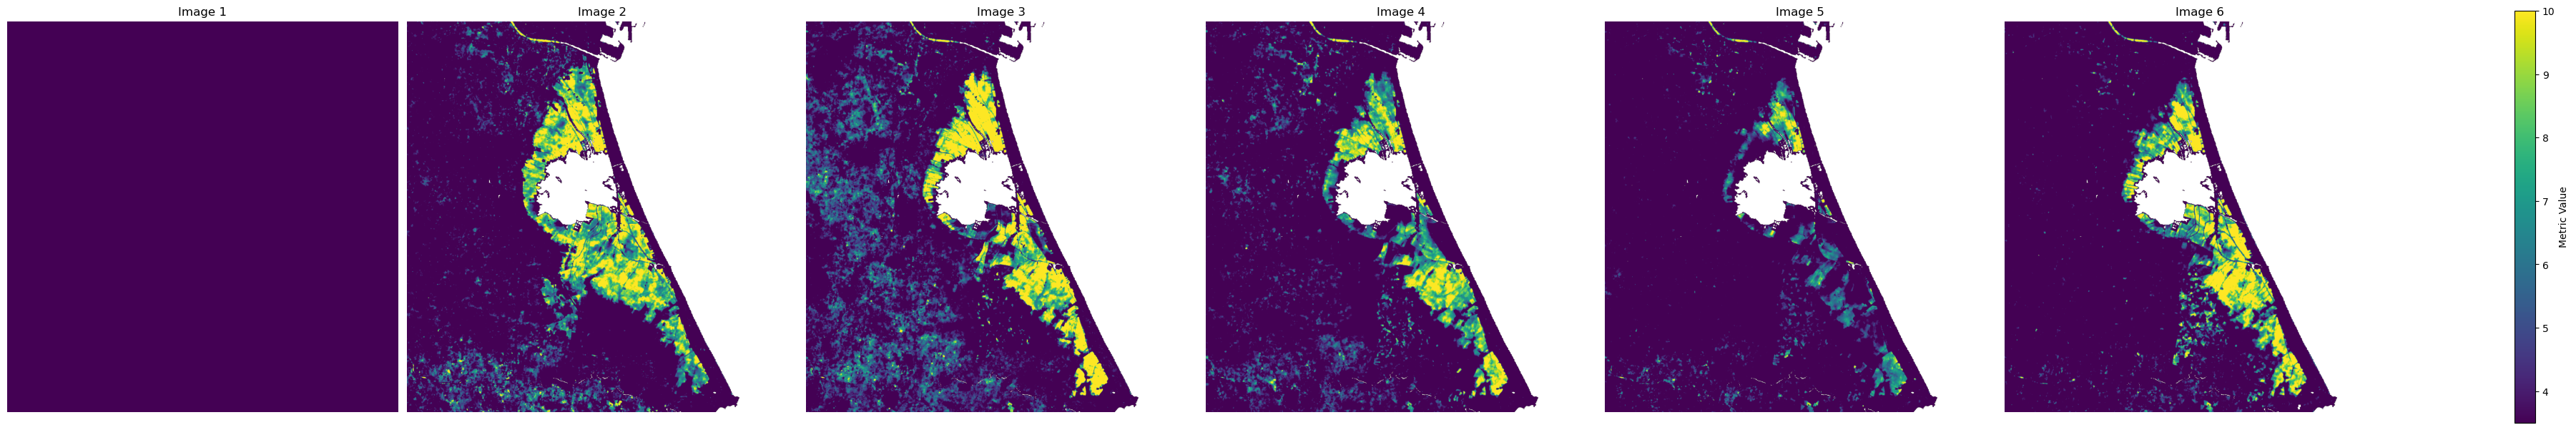

In [9]:
# Plot loaded metrics
num_files = len(metric_arrays)

fig, axes = plt.subplots(1, num_files, figsize=(num_files * 6, 6), constrained_layout=True)
# If there's only one image, axes will be a single axis
if num_files == 1:
    axes = [axes]

# Plot each 2D array in the list
im = None
for i, ax in enumerate(axes):
    im = ax.imshow(metric_arrays[i], vmin=3.5, vmax=10, cmap='viridis') # adjust vmin and vmax as desired
    ax.set_title(f"Image {i+1}")
    ax.axis('off') 

fig.colorbar(im, ax=axes, orientation='vertical', label='Metric Value')
plt.show()

#### Confirmation process

In [10]:
def collect_confirmation_hlslike(
    dist_metric: np.ndarray,
    dist_product_date: datetime,
    prev_consecutive_dist_count: Optional[np.ndarray] = None,
    prev_dist_product_date: Optional[datetime] = None,
    prev_first_conf_date: Optional[np.ndarray] = None,
    prev_latest_conf_date: Optional[np.ndarray] = None,
    prev_observation_num: Optional[np.ndarray] = None,
    prev_max_metric: Optional[np.ndarray] = None,
    prev_confidence: Optional[np.ndarray] = None,
    confidence_threshold: float = 3**2 * 3.5,
    moderate_threshold: float = 3.5,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    dist_s1_start_date = datetime(2024, 1, 1)
    days_since_start = (dist_product_date - dist_s1_start_date).days
    shape = dist_metric.shape
    non_empty_pixels = ~np.isnan(dist_metric)

    if days_since_start < 12:
        print(f"Acquisition closest to start date: {dist_product_date.strftime('%b %d, %Y')}")
        consecutive_dist_count = (dist_metric >= moderate_threshold).astype(int)
        observation_num = np.where(non_empty_pixels, 1, 0)
        valid_pixel_mask = non_empty_pixels & (consecutive_dist_count != 0)
        mean_metric = np.zeros(shape)
        mean_metric[valid_pixel_mask] += (
            (dist_metric[valid_pixel_mask] - mean_metric[valid_pixel_mask]) /
            consecutive_dist_count[valid_pixel_mask]
        )
        max_metric = np.where(dist_metric >= moderate_threshold, dist_metric, 0)
        confidence = (consecutive_dist_count ** 2) * mean_metric
        confirmed_dist = np.zeros_like(dist_metric)
        first_confirmed_date = np.zeros_like(dist_metric)
        latest_confirmed_date = np.zeros_like(dist_metric)

        return (
            observation_num,
            consecutive_dist_count,
            confirmed_dist,
            first_confirmed_date,
            latest_confirmed_date,
            max_metric,
            confidence,
        )

    # Validate required previous data
    required = [prev_consecutive_dist_count, prev_dist_product_date, prev_first_conf_date, prev_observation_num]
    if any(x is None for x in required):
        raise ValueError("Missing previous product data for non-initial acquisitions.")
    if prev_dist_product_date >= dist_product_date:
        raise ValueError("Previous product date must be earlier than current product date.")

    # Observation count
    observation_num = non_empty_pixels.astype(int) + prev_observation_num

    # Identify disturbed and undisturbed pixels
    above_threshold = dist_metric >= moderate_threshold
    below_threshold = ~above_threshold & non_empty_pixels

    # Initialize updated consecutive_dist_count
    consecutive_dist_count = np.zeros_like(dist_metric, dtype=int)

    # Case 1: Pixels above threshold → increment
    consecutive_dist_count[above_threshold] = prev_consecutive_dist_count[above_threshold] + 1

    # Case 2: Pixels below threshold → apply negative tracking only if prev count is positive
    neg_track_mask = below_threshold & (prev_consecutive_dist_count > 0)
    consecutive_dist_count[neg_track_mask] = -1 * prev_consecutive_dist_count[neg_track_mask]

    # Case 3: Reset if already tracking negatively
    reset_mask = below_threshold & (prev_consecutive_dist_count < 0)
    consecutive_dist_count[reset_mask] = 0

    # Max metric update
    max_metric = np.where(above_threshold, np.fmax(dist_metric, prev_max_metric), 0)

    # Extract previous mean metric from confidence
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_metric = np.where(prev_consecutive_dist_count != 0,
                               prev_confidence / (prev_consecutive_dist_count ** 2), 0)

    # Update mean metric only for those above threshold and with positive count
    valid_pixel_mask = above_threshold & (consecutive_dist_count > 0)
    mean_metric[valid_pixel_mask] += (
        (dist_metric[valid_pixel_mask] - mean_metric[valid_pixel_mask]) /
        consecutive_dist_count[valid_pixel_mask]
    )

    # Recalculate confidence
    confidence = (consecutive_dist_count ** 2) * mean_metric

    # Confirmed disturbance where confidence exceeds threshold
    confirmed_dist = (confidence > confidence_threshold).astype(int)

    # Update confirmation dates
    update_mask = (confidence > confidence_threshold) & (prev_confidence < confidence_threshold)
    first_confirmed_date = prev_first_conf_date.copy()
    first_confirmed_date[update_mask] = days_since_start

    latest_confirmed_date = np.where(confirmed_dist, days_since_start, prev_latest_conf_date)

    return (
        observation_num,
        consecutive_dist_count,
        confirmed_dist,
        first_confirmed_date,
        latest_confirmed_date,
        max_metric,
        confidence,
    )

In [11]:
# Function to iterate over multiple time steps, this function is used here 
# to exemplify the confirmation process, but is not part of the confirmation process.
def process_hls_confirm(arrays, dates):
    results = []
    consecutive_dist_count = None
    first_date_confirmed = None
    latest_date_confirmed = None
    observation_num = None
    max_metric = None
    confidence = None
    
    for i, (array, date) in enumerate(zip(arrays, dates)):
        prev_consecutive_dist_count = consecutive_dist_count if i > 0 else None
        prev_dist_product_date = dates[i - 1] if i > 0 else None
        prev_max_metric = max_metric if i > 0 else None
        prev_confidence = confidence if i > 0 else None
        
        result = collect_confirmation_hlslike(array, date, prev_consecutive_dist_count, prev_dist_product_date, first_date_confirmed, latest_date_confirmed, observation_num, prev_max_metric, prev_confidence)
        results.append(result)
        
        # Update tracking variables
        consecutive_dist_count = result[1]
        first_date_confirmed = result[3]
        latest_date_confirmed = result[4]
        observation_num = result[0]
        max_metric = result[5]
        confidence = result[6]
        
    return results

In [12]:
# Plot all results from confirmation process
def plot_disturbance_results(results, value_ranges=None):
    labels = ["Number of observations", "Consecutive disturbances", "Confirmed disturbance",
              "First confirmed date", "Latest confirmed date", "Max metric", "Confidence"]

    # Define manual min/max ranges for each variable (must match the labels order)
    if value_ranges is None:
        value_ranges = [
            (0, 20),    # Number of observations
            (0, 5),     # Consecutive disturbances
            (0, 1),     # Confirmed disturbance (binary)
            (0, 365),   # First confirmed date (e.g., relative DOY or date index)
            (0, 365),   # Latest confirmed date
            (0, 10),    # Max metric
            (0, 100)    # Confidence value
        ]

    n_steps = len(results)
    fig, axes = plt.subplots(n_steps, len(labels), figsize=(22, 2.8 * n_steps))

    for i, (observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence) in enumerate(results):
        data_list = [observation_num, consecutive_dist_count, confirmed_dist, first_confirmed_date, latest_confirmed_date, max_metric, confidence]

        for j, data in enumerate(data_list):
            ax = axes[i, j] if n_steps > 1 else axes[j]

            # Apply manual vmin/vmax
            vmin, vmax = value_ranges[j]

            im = ax.imshow(data, cmap='copper', interpolation='none', vmin=vmin, vmax=vmax)
            ax.set_title(labels[j] if i == 0 else "")
            ax.set_xticks([])
            ax.set_yticks([])

            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

#### Run confirmation and plot resutls

Acquisition closest to start date: Jan 10, 2024


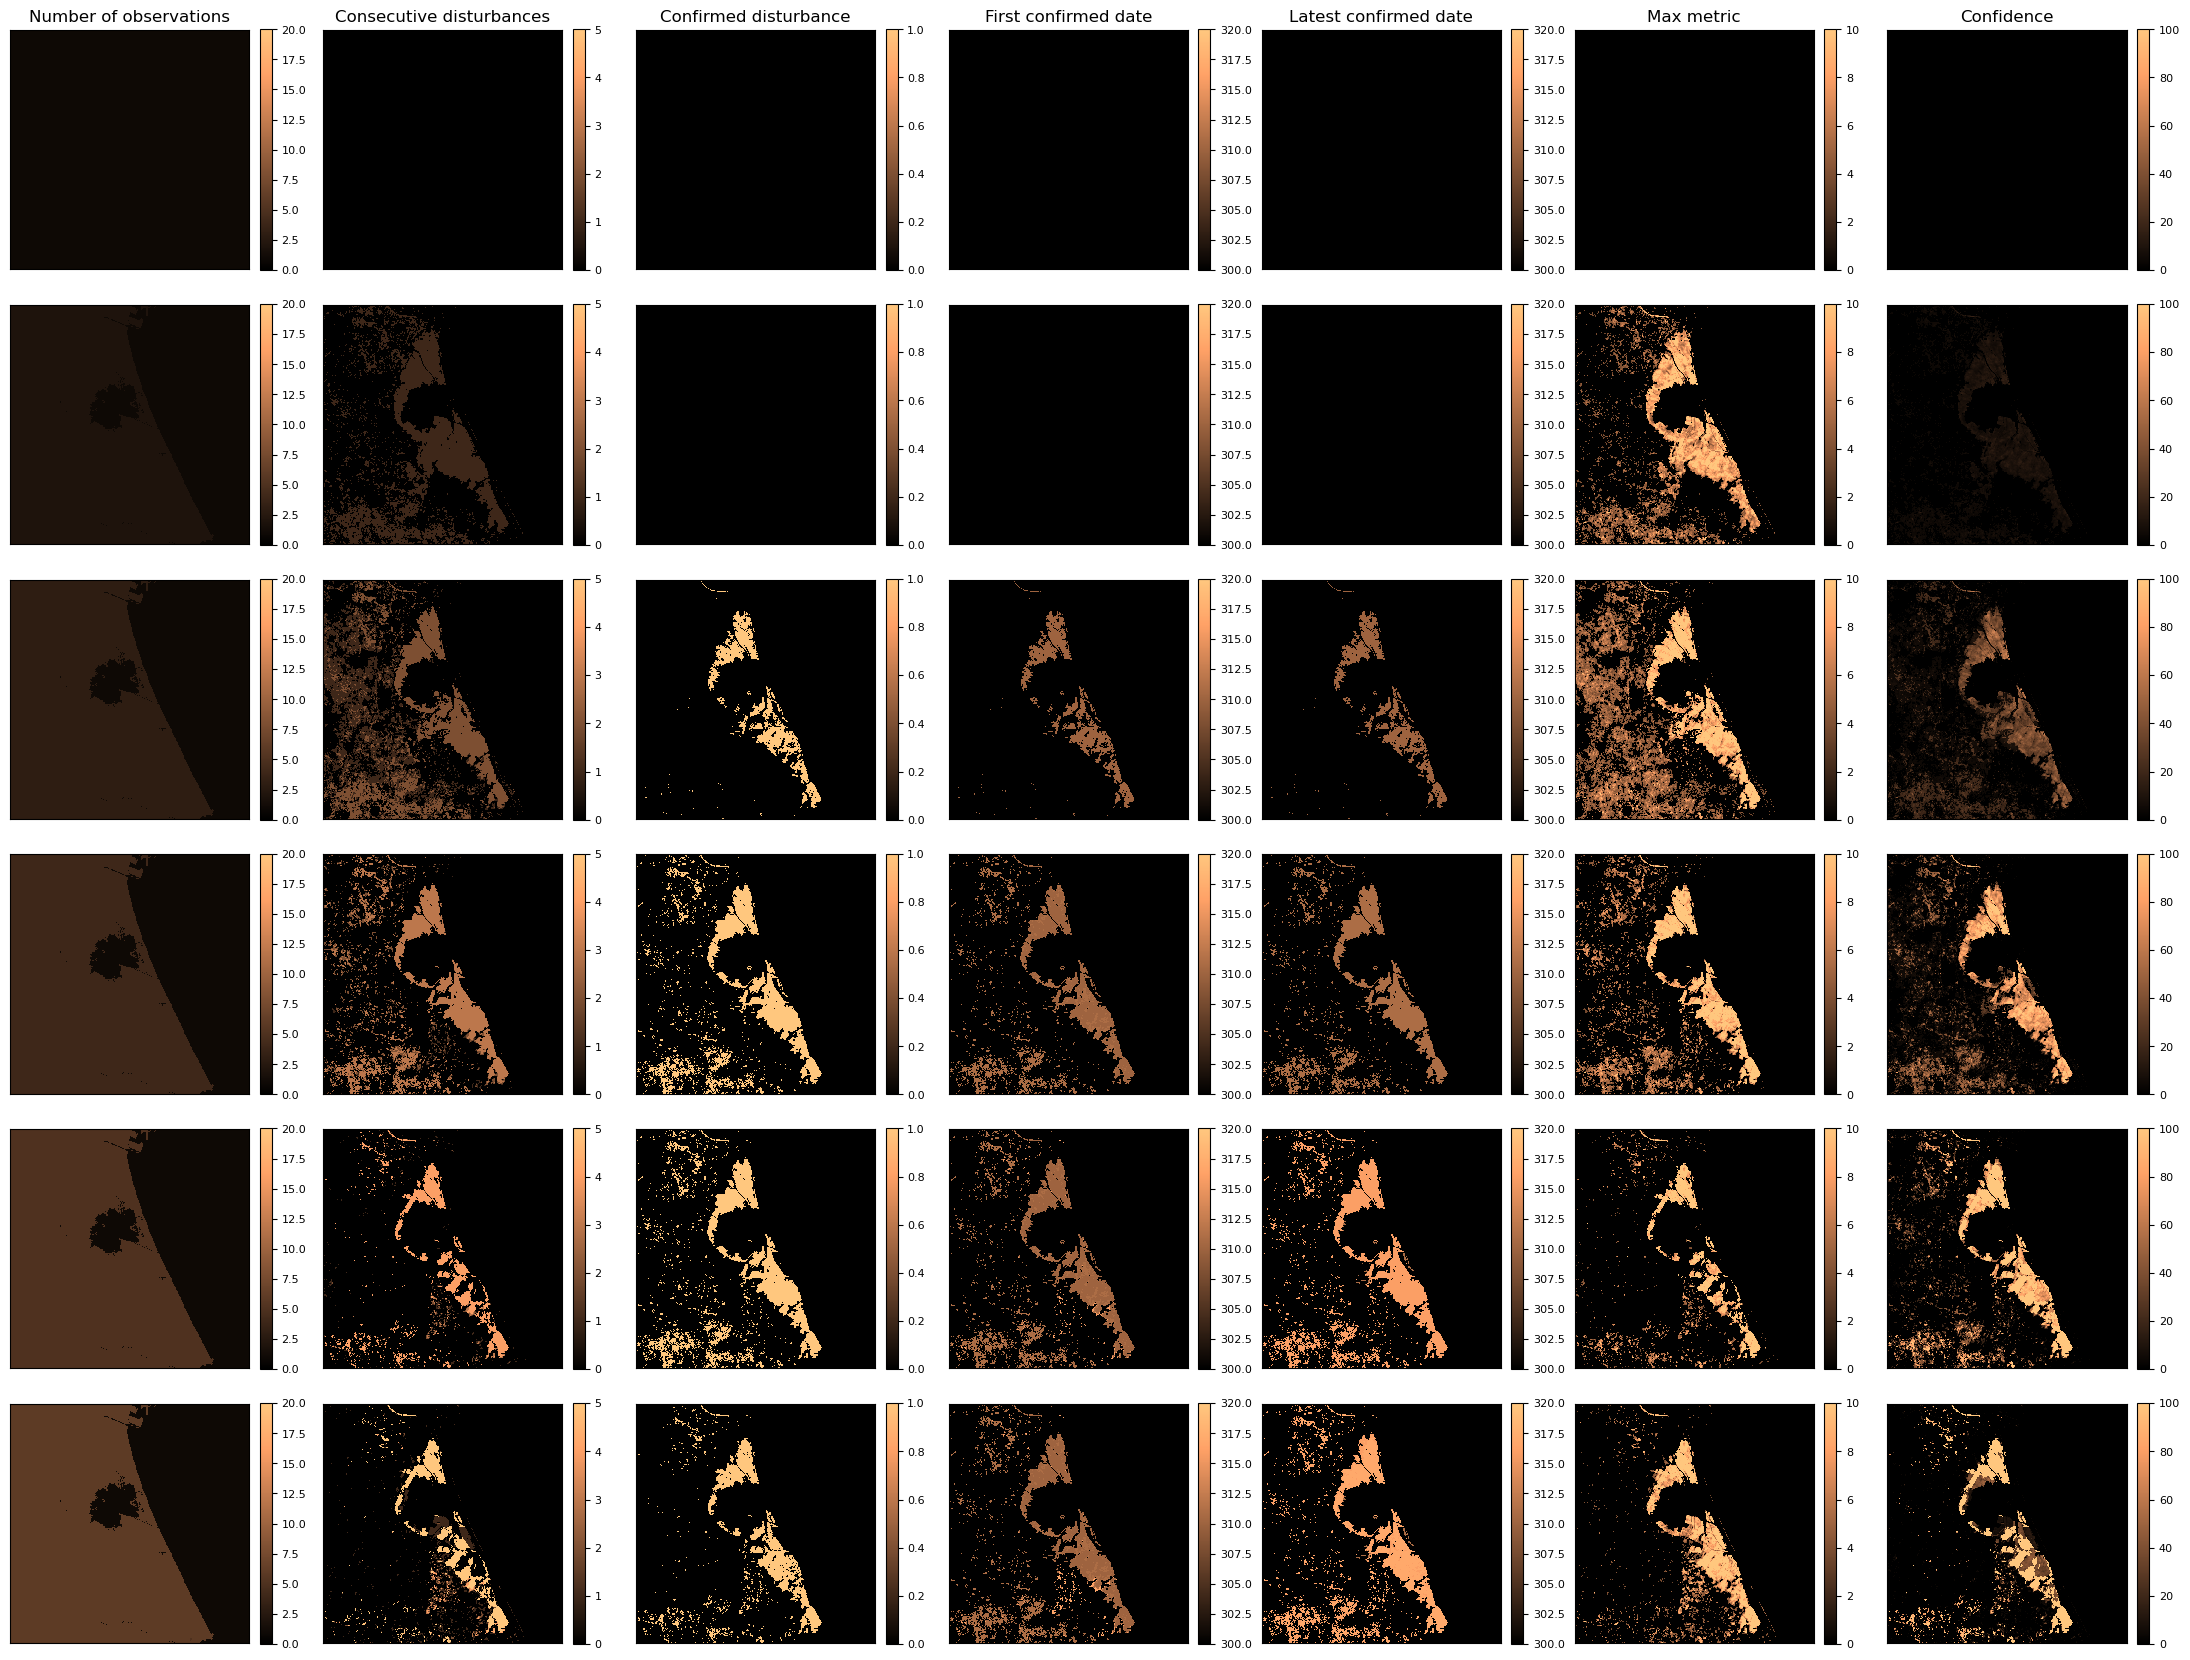

In [13]:
resutls = process_hls_confirm(metric_arrays, dist_product_dates)
# custom ranges for plotting
custom_ranges = [
    (0, 20), (0, 5), (0, 1), (300, 320), (300, 320), (0, 10), (0, 100)
]
plot_disturbance_results(resutls, value_ranges=custom_ranges)

#### Simulated example
The following example is composed by 20 acquisitions with a circular signal that appears and dissapears.  

In [14]:
def generate_array_series(num_arrays=20, size=20, max_val=30):
    arrays = []

    # Create a 2D Gaussian centered in the middle
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    xv, yv = np.meshgrid(x, y)
    gauss = np.exp(-(xv**2 + yv**2) * 5)  # Sharper peak with factor 5
    gauss = gauss / gauss.max() * max_val

    for i in range(num_arrays):
        # Two full cycles: each 10 frames long 
        cycle_pos = i % 10  # Position in current cycle (0–9)

        # Define scale for each phase of the cycle
        if cycle_pos < 2:
            scale = 0  # fully off
        elif 2 <= cycle_pos <= 4:
            scale = (cycle_pos - 2) / 3  # ramp up: 0 → 1
        elif cycle_pos == 5:
            scale = 1  # fully on
        elif 6 <= cycle_pos <= 7:
            scale = 1 - (cycle_pos - 5) / 2  # ramp down: 1 → 0
        else:
            scale = 0  # fully off again

        frame = gauss * scale

        # Randomly apply NaNs to simulate missing data
        nan_mask = np.random.rand(size, size) < 0.1  # 10% NaNs
        frame[nan_mask] = np.nan

        arrays.append(frame)

    return arrays

# Example usage:
arrays = generate_array_series()

#### Generate list of dates

In [15]:
# Generate dates starting from Jan 1, 2024, with 12-day intervals
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=i * 12) for i in range(len(arrays))]

# Display the generated dates
dates

[datetime.datetime(2024, 1, 1, 0, 0),
 datetime.datetime(2024, 1, 13, 0, 0),
 datetime.datetime(2024, 1, 25, 0, 0),
 datetime.datetime(2024, 2, 6, 0, 0),
 datetime.datetime(2024, 2, 18, 0, 0),
 datetime.datetime(2024, 3, 1, 0, 0),
 datetime.datetime(2024, 3, 13, 0, 0),
 datetime.datetime(2024, 3, 25, 0, 0),
 datetime.datetime(2024, 4, 6, 0, 0),
 datetime.datetime(2024, 4, 18, 0, 0),
 datetime.datetime(2024, 4, 30, 0, 0),
 datetime.datetime(2024, 5, 12, 0, 0),
 datetime.datetime(2024, 5, 24, 0, 0),
 datetime.datetime(2024, 6, 5, 0, 0),
 datetime.datetime(2024, 6, 17, 0, 0),
 datetime.datetime(2024, 6, 29, 0, 0),
 datetime.datetime(2024, 7, 11, 0, 0),
 datetime.datetime(2024, 7, 23, 0, 0),
 datetime.datetime(2024, 8, 4, 0, 0),
 datetime.datetime(2024, 8, 16, 0, 0)]

In [16]:
def plot_array_series(arrays, dates):
    num_arrays = len(arrays)

    # Compute a nearly square grid layout using NumPy
    cols = int(np.ceil(np.sqrt(num_arrays)))
    rows = int(np.ceil(num_arrays / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        ax = axes[i]
        if i < num_arrays:
            ax.imshow(arrays[i], cmap='viridis', vmin=0, vmax=10)
            ax.set_title(dates[i].strftime("%b %d, %Y"))
        ax.axis("off")  # Hide axis for all subplots
        cbar = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

#### Visualize simulated example

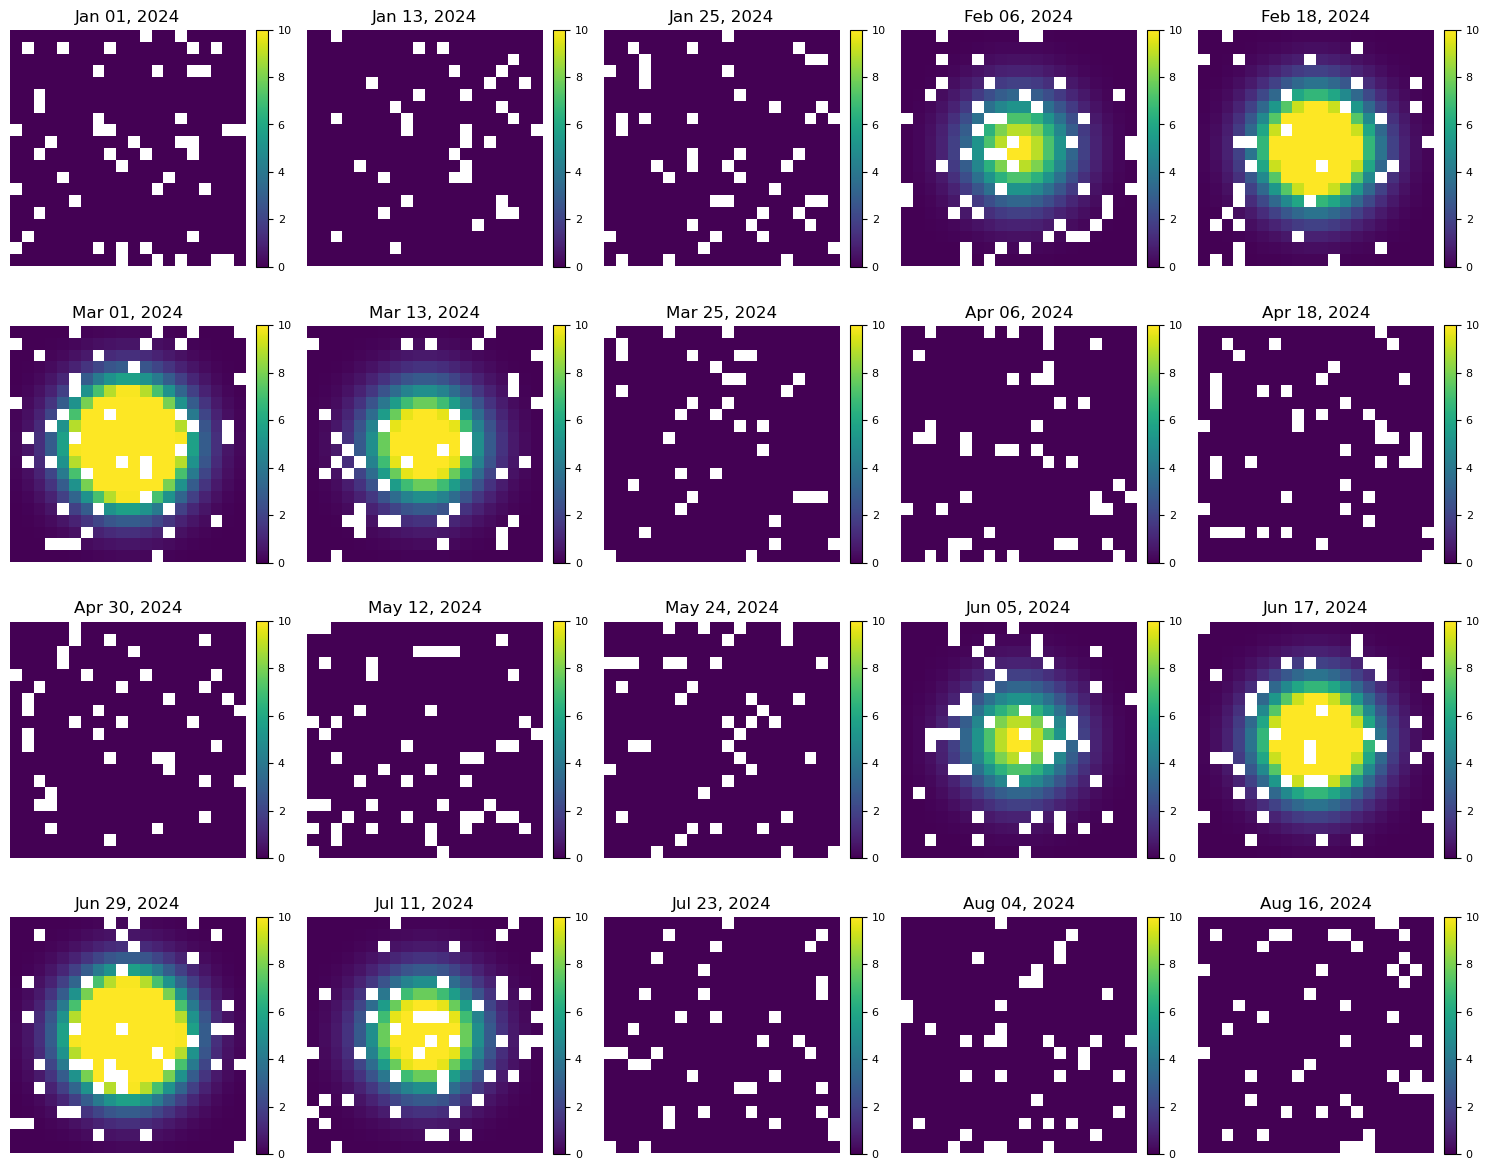

In [17]:
plot_array_series(arrays, dates)

#### Run confirmation and plot results

Acquisition closest to start date: Jan 01, 2024


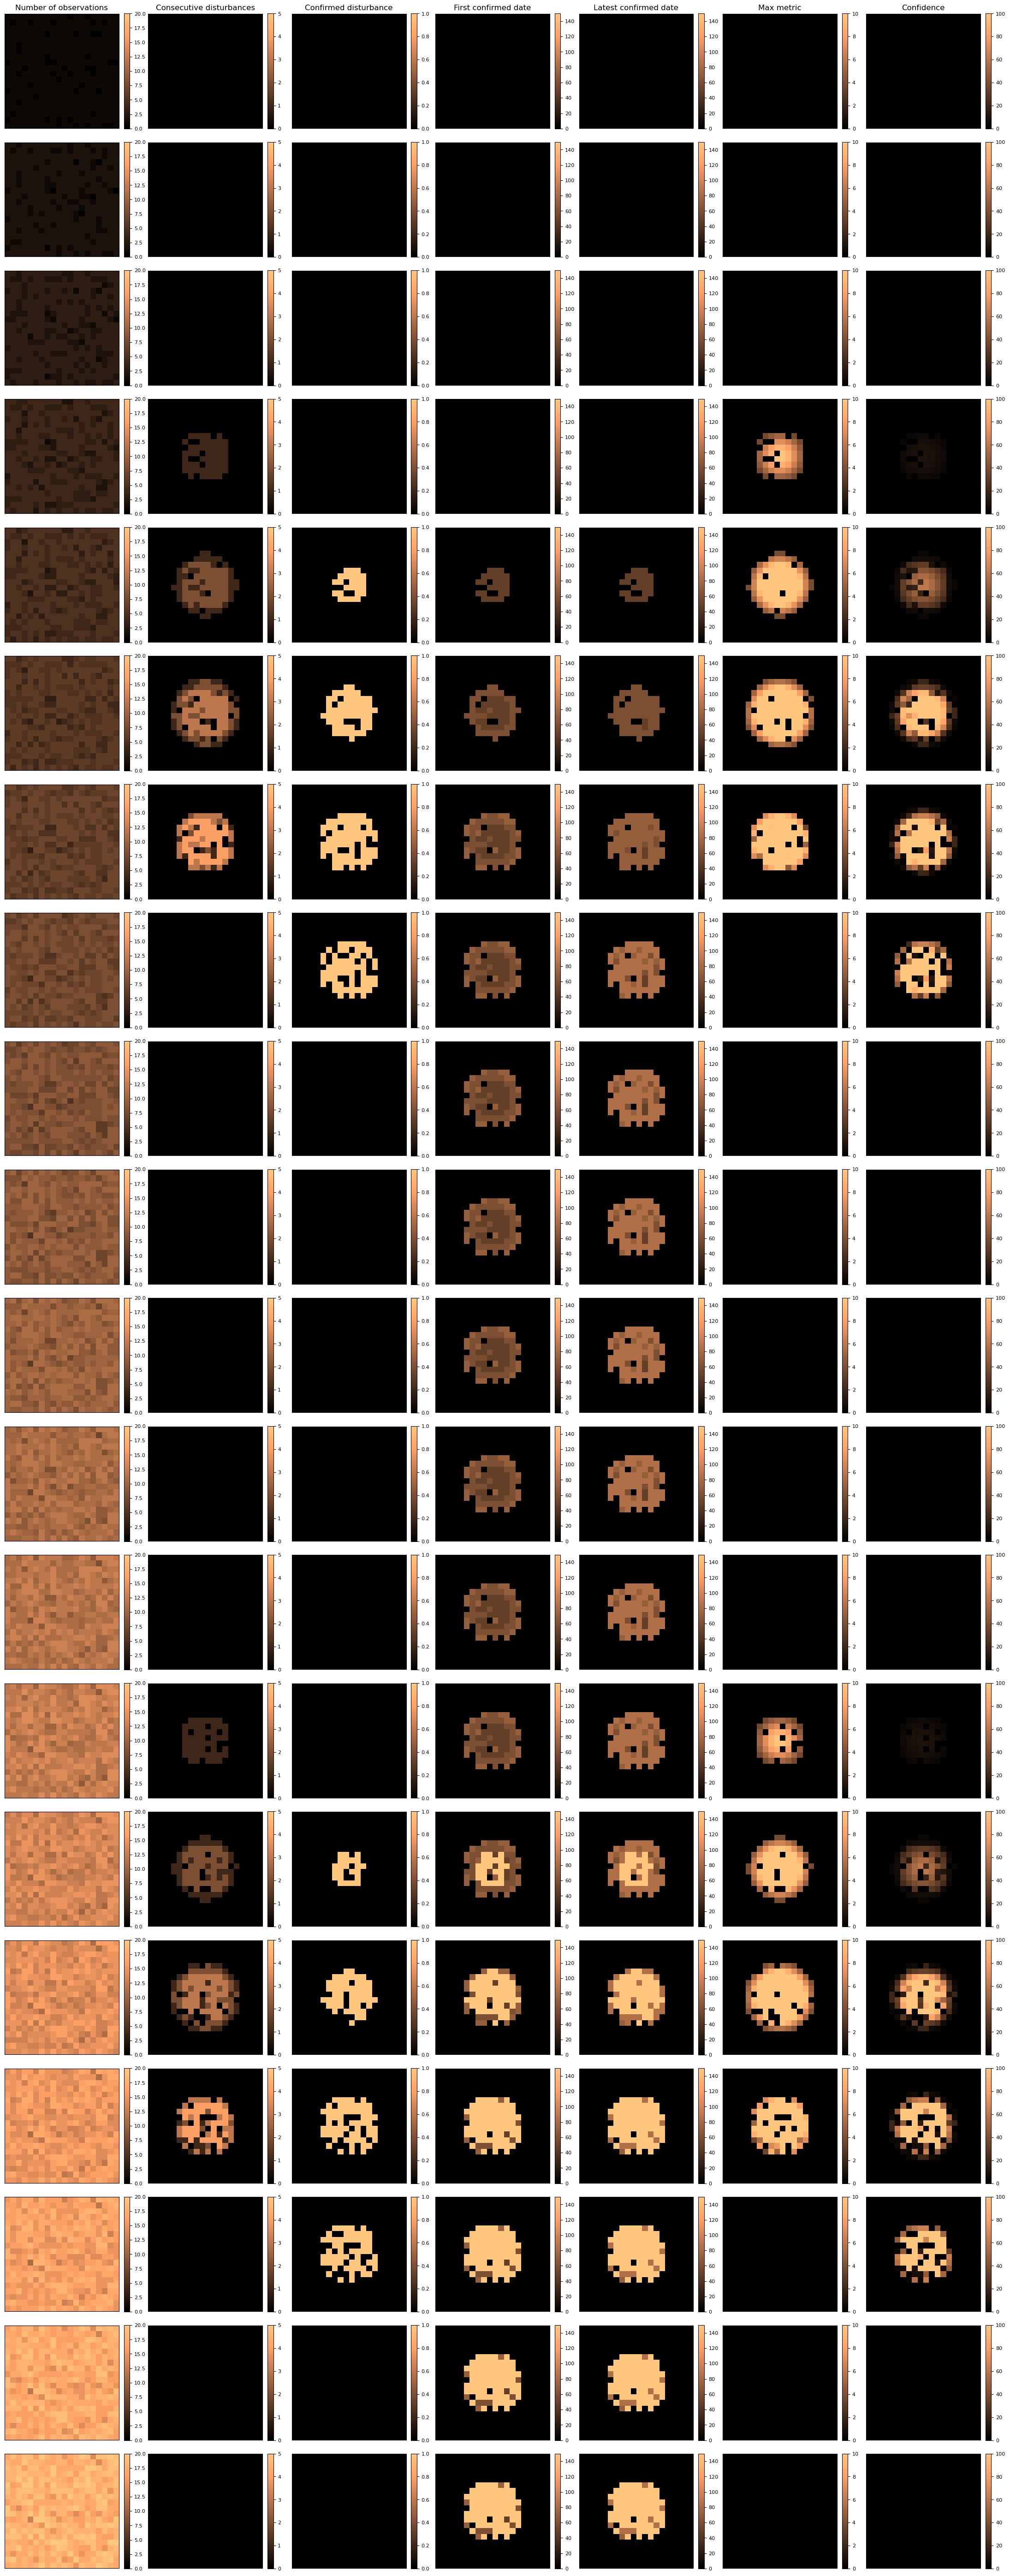

In [18]:
resutls = process_hls_confirm(arrays, dates)
# custom ranges for plotting
custom_ranges = [
    (0, 20), (0, 5), (0, 1), (0, 150), (0, 150), (0, 10), (0, 100)
]
plot_disturbance_results(resutls, value_ranges=custom_ranges)

### Pseudo code of the confirmation process

Function collect_confirmation_hlslike(dist_metric, dist_product_date, [optional previous inputs]):
    Define start_date = Jan 1, 2024
    Compute days_since_start from dist_product_date - start_date
    Get shape of dist_metric
    Identify valid pixels (non-empty)

    If this is the first acquisition (i.e., days_since_start < 12):
        Print debug message
        For each pixel:
            If metric >= moderate threshold:
                Set consecutive_dist_count = 1
                Add metric to mean_metric
                Set max_metric = current metric
            Else:
                Set consecutive_dist_count = 0
        Compute confidence = (consecutive_dist_count)^2 * mean_metric
        Initialize confirmed disturbance and date arrays to zero
        Return initial state arrays

    Validate that required previous inputs exist
    Ensure previous date < current date

    Update observation count += 1 for valid pixels

    Classify pixels as:
        - Above threshold
        - Below threshold (but still valid)

    Initialize consecutive_dist_count to zeros

    For pixels above threshold:
        Increase consecutive_dist_count by 1

    For pixels below threshold:
        If previous count > 0:
            Start negative tracking → set count to negative value
        Else if previous count < 0:
            Reset count to 0

    For pixels above threshold:
        Update max_metric = max(current, previous)

    Extract mean_metric from previous confidence:
        mean_metric = confidence / (consecutive_count^2)

    For valid pixels above threshold and with positive count:
        Update mean_metric using rolling mean formula

    Compute confidence = (consecutive_dist_count)^2 * mean_metric

    Identify confirmed disturbances:
        confidence > threshold → mark as confirmed

    Update confirmation dates:
        If pixel becomes newly confirmed:
            Set first confirmation date = current day
        For all confirmed pixels:
            Set latest confirmation date = current day
        Else:
            Keep previous latest confirmation date

    Return updated arrays:
        observation_num,
        consecutive_dist_count,
        confirmed_dist,
        first_confirmed_date,
        latest_confirmed_date,
        max_metric,
        confidence
